In [2]:
%matplotlib notebook 
import math
import time
import jax
import copy

import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.mplot3d import Axes3D
from tueplots import bundles
from tueplots import cycler
from tueplots import markers
from tueplots.constants.color import palettes
from tueplots.constants.color import rgb

In [38]:
plt.rcParams.update({"figure.dpi": 500})
plt.rcParams.update(bundles.iclr2023())
plt.rcParams.update(cycler.cycler(color=palettes.tue_plot))
plt.rcParams.update(markers.inverted())

In [4]:
X1_1 = 0.2
X1_2 = 0.6
T1 = 0.9
X2_1 = 0.5
X2_2 = -1.1
T2 = 0.3
X3_1 = 0.4
X3_2 = 0.1
T3 = 0.5

# Design matrix
X = jnp.array([[X1_1, X1_2], [X2_1, X2_2], [X3_1, X3_2]])
T = jnp.array([[T1], [T2], [T3]])
X2 = jnp.array([[X2_1], [X2_2]])

In [11]:
@jax.jit
def loss_fnc(params, eps=0):
    w1 = params["w1"]
    w2 = params["w2"]
    loss1 = (jax.nn.sigmoid(X1_1 * w1 + X1_2 * w2) - T1) ** 2.
    loss2 = (jax.nn.sigmoid(X2_1 * w1 + X2_2 * w2) - T2) ** 2.
    loss3 = (jax.nn.sigmoid(X3_1 * w1 + X3_2 * w2) - T3) ** 2.
    return 0.5 * jnp.sum((loss1 + loss2 - loss2 * eps + loss3))


def loss2_fnc(params):
    w1 = params["w1"]
    w2 = params["w2"]
    return 0.5 * jnp.sum((jax.nn.sigmoid(X2_1 * w1 + X2_2 * w2) - T2) ** 2.)


def optimum(eps, total_its=1001, w1_init=0, w2_init=0):
    grad_fn = jax.grad(loss_fnc)


    def update(_params, _grads):
        return jax.tree_util.tree_map(lambda p, g: p - 1. * g, _params, _grads)

    def update_half(_params, _grads):
        return jax.tree_util.tree_map(lambda p, g: p - 0.1 * g, _params, _grads)


    params = {
        "w1": jnp.ones(1,) * w1_init,
        "w2": jnp.ones(1,) * w2_init
    }

    for it in range(total_its):
        loss = loss_fnc(params, eps=eps)
        if it % 500 == 0:
            print("it=" + str(it) +
                  " loss=" + str(loss))
        grads = grad_fn(params, eps=eps)
        if it < 500:
            params = update(params, grads)
        else:
            params = update_half(params, grads)
    return params

In [12]:
class LogNormalize(colors.Normalize):
    def __init__(self, vmin=None, vmax=None, clip=None, log_alpha=None):
        self.log_alpha = log_alpha
        colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        log_v = np.ma.log(value - self.vmin)
        log_v = np.ma.maximum(log_v, self.log_alpha)
        return 0.9 * (log_v - self.log_alpha) / (np.log(self.vmax - self.vmin) - self.log_alpha)

In [13]:
opt_eps_0 = optimum(eps=0)
opt_eps_half = optimum(eps=0.5)
opt_eps_1 = optimum(eps=1)

it=0 loss=0.09999999
it=500 loss=0.021902166
it=1000 loss=0.021902164
it=0 loss=0.08999999
it=500 loss=0.019013625
it=1000 loss=0.019013528
it=0 loss=0.07999999
it=500 loss=0.00042880877
it=1000 loss=0.00032170696


In [14]:
cost_hess = jax.hessian(loss_fnc)(opt_eps_0, 0)
cost_grad = jax.grad(loss_fnc)(opt_eps_0, 0)
loss_hess = jax.hessian(loss2_fnc)(opt_eps_0)
loss_grad = jax.grad(loss2_fnc)(opt_eps_0)

cost_hess = jnp.array([[cost_hess["w1"]["w1"].item(), 
                           cost_hess["w1"]["w2"].item()], 
                          [cost_hess["w1"]["w2"].item(), 
                           cost_hess["w2"]["w2"].item()]])
loss_hess = jnp.array([[loss_hess["w1"]["w1"].item(), 
                           loss_hess["w1"]["w2"].item()], 
                          [loss_hess["w1"]["w2"].item(), 
                           loss_hess["w2"]["w2"].item()]])
cost_grad = jnp.array([[cost_grad["w1"].item()], [cost_grad["w2"].item()]])
loss_grad = jnp.array([[loss_grad["w1"].item()], [loss_grad["w2"].item()]])
current_param = jnp.array([[opt_eps_0["w1"].item()], [opt_eps_0["w2"].item()]])

In [15]:
def find_quadratic_argmin(k=5):
    current_param = jnp.array([[opt_eps_0["w1"].item()], [opt_eps_0["w2"].item()]])
    eps_list = np.linspace(-0.3, 1., k)
    w1_list = []
    w2_list = []
    for eps in eps_list:
        lin_brj = jnp.linalg.inv(cost_hess - loss_hess * eps) @ loss_grad * eps
        current_w1 = current_param[0] + lin_brj[0].item()
        current_w2 = current_param[1] + lin_brj[1].item()
        w1_list.append(current_w1.item())
        w2_list.append(current_w2.item())
    return w1_list, w2_list, list(eps_list)

In [16]:
def find_linearized_argmin(k=5):
    current_param = jnp.array([[opt_eps_0["w1"].item()], [opt_eps_0["w2"].item()]])
    eps_list = np.linspace(-0.3, 1., k)
    w1_list = []
    w2_list = []
    for eps in eps_list:
        brj = jnp.linalg.inv(cost_hess) @ loss_grad * eps
        current_w1 = current_param[0] + brj[0].item()
        current_w2 = current_param[1] + brj[1].item()
        w1_list.append(current_w1.item())
        w2_list.append(current_w2.item())
    return w1_list, w2_list, list(eps_list)

In [17]:
def find_numerical_grad_argmin(k=5):
    eps_list = np.linspace(0, 1, k)
    w1_list = []
    w2_list = []
    for eps in eps_list:
        current_param = optimum(eps=eps)
        w1_list.append(current_param["w1"].item())
        w2_list.append(current_param["w2"].item())
    return w1_list, w2_list, eps_list

In [18]:
g1, g2, g3 = find_numerical_grad_argmin(k=30)

it=0 loss=0.09999999
it=500 loss=0.021902166
it=1000 loss=0.021902164
it=0 loss=0.09931033
it=500 loss=0.021810591
it=1000 loss=0.021810587
it=0 loss=0.098620676
it=500 loss=0.021711623
it=1000 loss=0.02171163
it=0 loss=0.09793102
it=500 loss=0.021604344
it=1000 loss=0.021604337
it=0 loss=0.097241364
it=500 loss=0.021487558
it=1000 loss=0.021487553
it=0 loss=0.09655171
it=500 loss=0.021359945
it=1000 loss=0.021359956
it=0 loss=0.09586205
it=500 loss=0.021219874
it=1000 loss=0.021219872
it=0 loss=0.0951724
it=500 loss=0.021065319
it=1000 loss=0.02106531
it=0 loss=0.09448274
it=500 loss=0.020893792
it=1000 loss=0.020893788
it=0 loss=0.093793094
it=500 loss=0.020702163
it=1000 loss=0.020702152
it=0 loss=0.09310344
it=500 loss=0.020486392
it=1000 loss=0.020486383
it=0 loss=0.09241378
it=500 loss=0.0202412
it=1000 loss=0.020241184
it=0 loss=0.09172413
it=500 loss=0.019959372
it=1000 loss=0.019959351
it=0 loss=0.09103447
it=500 loss=0.019630665
it=1000 loss=0.019630658
it=0 loss=0.09034482
i

In [19]:
min_w1 = np.min([opt_eps_0["w1"].item(), opt_eps_half["w1"].item(), opt_eps_1["w1"].item()])
max_w1 = np.max([opt_eps_0["w1"].item(), opt_eps_half["w1"].item(), opt_eps_1["w1"].item()])
min_w2 = np.min([opt_eps_0["w2"].item(), opt_eps_half["w2"].item(), opt_eps_1["w2"].item()])
max_w2 = np.max([opt_eps_0["w2"].item(), opt_eps_half["w2"].item(), opt_eps_1["w2"].item()])

w1_list = jnp.linspace(min_w1 - 2, max_w1 + 2, 100)
w2_list = jnp.linspace(min_w2 - 2, max_w2 + 2, 100)
loss_list_0 = np.zeros((100, 100))
loss_list_half = np.zeros((100, 100))
loss_list_1 = np.zeros((100, 100))

for i, w1 in enumerate(w1_list):
    for j, w2 in enumerate(w2_list):
        _params = {
            "w1": jnp.ones(1,) * w1,
            "w2": jnp.ones(1,) * w2
        }
        loss_list_0[j, i] = loss_fnc(_params, eps=0)
        loss_list_half[j, i] = loss_fnc(_params, eps=0.5)
        loss_list_1[j, i] = loss_fnc(_params, eps=1)

In [20]:
log_alpha = -7
N = 9
cmap = plt.get_cmap("jet_r")

values = loss_list_0.copy()
log_gamma = (np.log(values.max() - values.min()) - log_alpha) / N
levels_0 = values.min() + np.exp(log_alpha + log_gamma * np.arange(N + 1))
levels_0[0] = values.min()
levels_0[-1] = values.max()
levels = np.concatenate((levels_0, [1e10]))
norm_0 = LogNormalize(values.min() - 1e-8, values.max() + 1e-8, log_alpha=log_alpha)

values = loss_list_half.copy()
log_gamma = (np.log(values.max() - values.min()) - log_alpha) / N
levels_half = values.min() + np.exp(log_alpha + log_gamma * np.arange(N + 1))
levels_half[0] = values.min()
levels_half[-1] = values.max()
levels = np.concatenate((levels_0, [1e10]))
norm_half = LogNormalize(values.min() - 1e-8, values.max() + 1e-8, log_alpha=log_alpha)

values = loss_list_1.copy()
log_gamma = (np.log(values.max() - values.min()) - log_alpha) / N
levels_1 = values.min() + np.exp(log_alpha + log_gamma * np.arange(N + 1))
levels_1[0] = values.min()
levels_1[-1] = values.max()
levels = np.concatenate((levels_0, [1e10]))
norm_1 = LogNormalize(values.min() - 1e-8, values.max() + 1e-8, log_alpha=log_alpha)

<IPython.core.display.Javascript object>


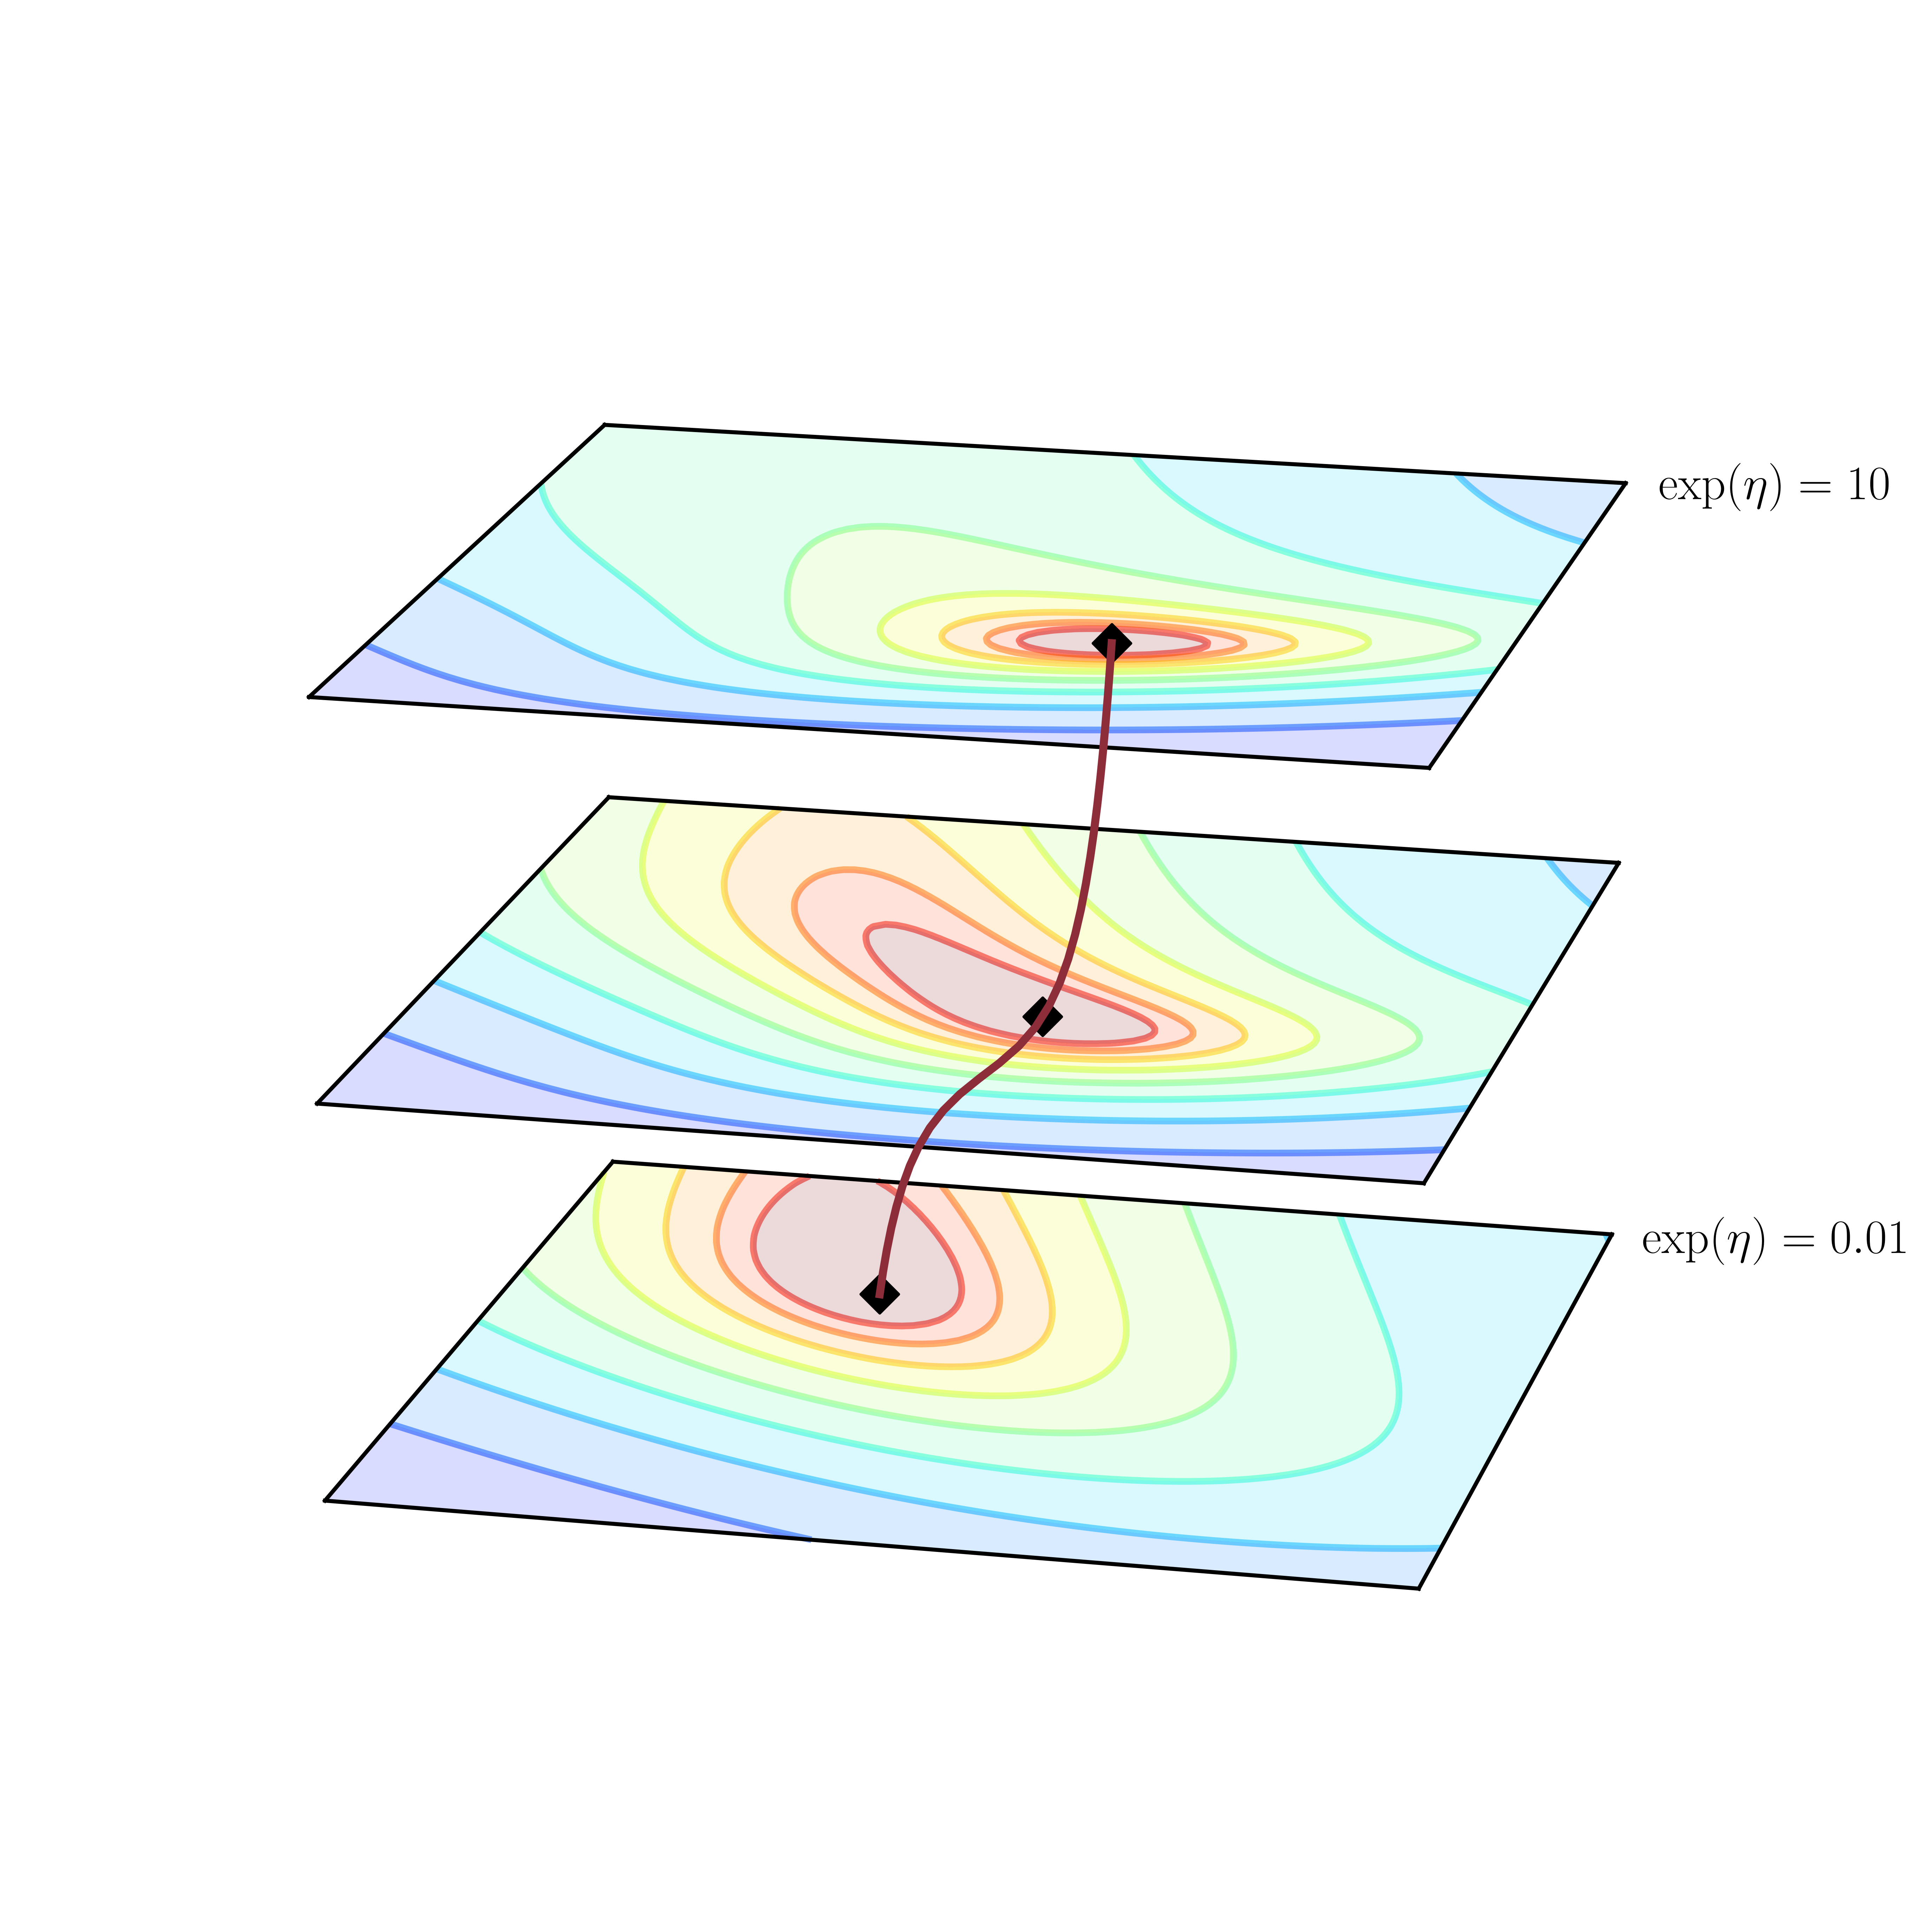

/home/baejuhan/anaconda3/envs/vae/lib/python3.7/site-packages/ipykernel_launcher.py:103: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


In [42]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Rectangle, PathPatch, Circle
import mpl_toolkits.mplot3d.art3d as art3d

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)

ax.scatter([opt_eps_1["w1"].item()], [opt_eps_1["w2"].item()], [1], s=100, marker="D", 
           color="k", edgecolor="k")
ax.plot(g1, g2, g3, zorder=3, linewidth=3)

# q1, q2, q3 = find_quadratic_argmin(k=50)
# ax.plot(q1, q2, q3, color="#EE8866", zorder=5)

# l1, l2, l3 = find_linearized_argmin(k=50)
# ax.plot(l1, l2, l3, color="k", zorder=5)

plt.contour(w1_list, w2_list, loss_list_0, cmap=cmap, norm=norm_0,
            linewidths=2.5,
            levels=levels_0,
            zorder=-1,
            offset=0,
            alpha=0.5)
plt.contourf(w1_list, w2_list, loss_list_0, cmap=cmap, norm=norm_0,
             alpha=0.15,
             zorder=-1,
             levels=levels_0,
             offset=0)
ax.scatter([opt_eps_0["w1"].item()], [opt_eps_0["w2"].item()], [0.], s=100, marker="D", 
           color="k", edgecolor="k")


ax.plot([min_w1 - 2, min_w1 - 2], [min_w2 - 2, max_w2 + 2], [0, 0], color="k")
ax.plot([max_w1 + 2, max_w1 + 2], [min_w2 - 2, max_w2 + 2], [0, 0], color="k")
ax.plot([min_w1 - 2, max_w1 + 2], [min_w2 - 2, min_w2 - 2], [0, 0], color="k")
ax.plot([max_w1 + 2, min_w1 - 2], [max_w2 + 2, max_w2 + 2], [0, 0], color="k")


plt.contour(w1_list, w2_list, loss_list_half, cmap=cmap, norm=norm_half,
            linewidths=2.5,
            zorder=-1,
            levels=levels_half,
            offset=0.5,
            alpha=0.5)
plt.contourf(w1_list, w2_list, loss_list_half, cmap=cmap, norm=norm_half,
             alpha=0.15,
             zorder=-1,
             levels=levels_half,
             offset=0.5)
ax.scatter([opt_eps_half["w1"].item()], [opt_eps_half["w2"].item()], [0.5], s=100, marker="D", 
           color="k", edgecolor="k")

ax.plot([min_w1 - 2, min_w1 - 2], [min_w2 - 2, max_w2 + 2], [0.5, 0.5], color="k")
ax.plot([max_w1 + 2, max_w1 + 2], [min_w2 - 2, max_w2 + 2], [0.5, 0.5], color="k")
ax.plot([min_w1 - 2, max_w1 + 2], [min_w2 - 2, min_w2 - 2], [0.5, 0.5], color="k")
ax.plot([max_w1 + 2, min_w1 - 2], [max_w2 + 2, max_w2 + 2], [0.5, 0.5], color="k")

plt.contour(w1_list, w2_list, loss_list_1, cmap=cmap, norm=norm_1,
            linewidths=2.5,
            zorder=-1,
            levels=levels_1,
            offset=1,
            alpha=0.5)
plt.contourf(w1_list, w2_list, loss_list_1, cmap=cmap, norm=norm_1,
             alpha=0.15,
             zorder=-1,
             levels=levels_1,
             offset=1)



ax.plot([min_w1 - 2, min_w1 - 2], [min_w2 - 2, max_w2 + 2], [1, 1], color="k")
ax.plot([max_w1 + 2, max_w1 + 2], [min_w2 - 2, max_w2 + 2], [1, 1], color="k")
ax.plot([min_w1 - 2, max_w1 + 2], [min_w2 - 2, min_w2 - 2], [1, 1], color="k")
ax.plot([max_w1 + 2, min_w1 - 2], [max_w2 + 2, max_w2 + 2], [1, 1], color="k")

ax.text(max_w1 + 2.9, max_w2 + 2.1, 1, r"$\exp(\eta) = 0.01$", 
        None, size=18, va="center", ha="center")
ax.text(max_w1 + 2.8, max_w2 + 2.1, 0, r"$\exp(\eta) = 10$", 
        None, size=18, va="center", ha="center")
# ax.scatter([q1[-1]], [q2[-1]], [1], s=230, marker="*", color="#EE8866", edgecolor="k", 
#            label="Quadratic Estimation", zorder=5)
# ax.scatter([l1[-1]], [l2[-1]], [1], s=230, marker="*", color="k", edgecolor="k", 
#            label="Influence Estimation", zorder=5)
ax.set_zlim(1., -0.1)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')
ax.grid(False)
ax.w_xaxis.line.set_color((1.0, 1.0, 1.0, 0.0)) 
ax.w_yaxis.line.set_color((1.0, 1.0, 1.0, 0.0)) 
ax.w_zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
ax.set_xticks([]) 
ax.set_yticks([]) 
ax.set_zticks([])

# plt.legend(fontsize=20, framealpha=0.5, ncol=1, borderaxespad=2, loc=2)
ax.view_init(elev=17., azim=-77)
plt.tight_layout(pad=0.)
# plt.subplots_adjust(left=0, bottom=-10, right=1, top=1, wspace=0, hspace=0)
plt.savefig("viz.pdf", bbox_inches='tight')